### **Libraries**

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,f1_score,roc_auc_score,classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import math

### **Data Preprocessing & EDA**
---

In [ ]:
df = pd.read_csv(
    "/content/online_shoppers_intention.csv"
    )
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
print("Shape:")
df.shape

Shape:


(12330, 18)

In [ ]:
print("Columns:")
df.columns

Columns:


Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [ ]:
print("Info:")
df.info()

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType     

In [ ]:
print("Description:")
df.describe()

Description:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [ ]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [ ]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
125


In [ ]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [ ]:
df.sample(5)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
9371,14,160.111539,6,1079.833333,154,7405.360281,0.004924,0.021453,8.533928,0.0,Nov,4,1,4,1,Returning_Visitor,False,True
9089,1,103.000000,0,0.000000,20,1140.666667,0.000000,0.005000,19.181088,0.0,Dec,3,2,3,2,New_Visitor,False,True
866,5,92.750000,1,74.750000,84,2756.215152,0.000000,0.002462,0.000000,0.0,Mar,2,2,9,3,New_Visitor,True,False
1978,0,0.000000,0,0.000000,9,388.000000,0.066667,0.088889,0.000000,0.0,Mar,3,2,2,1,Returning_Visitor,False,False
8974,0,0.000000,2,45.750000,42,1931.630952,0.000000,0.008333,0.000000,0.0,Dec,1,1,6,1,Returning_Visitor,True,False


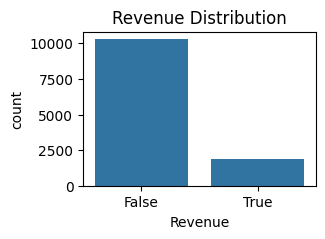

In [ ]:
plt.figure(figsize=(3, 2))
sns.countplot(x='Revenue', data=df)
plt.title('Revenue Distribution')
plt.show()

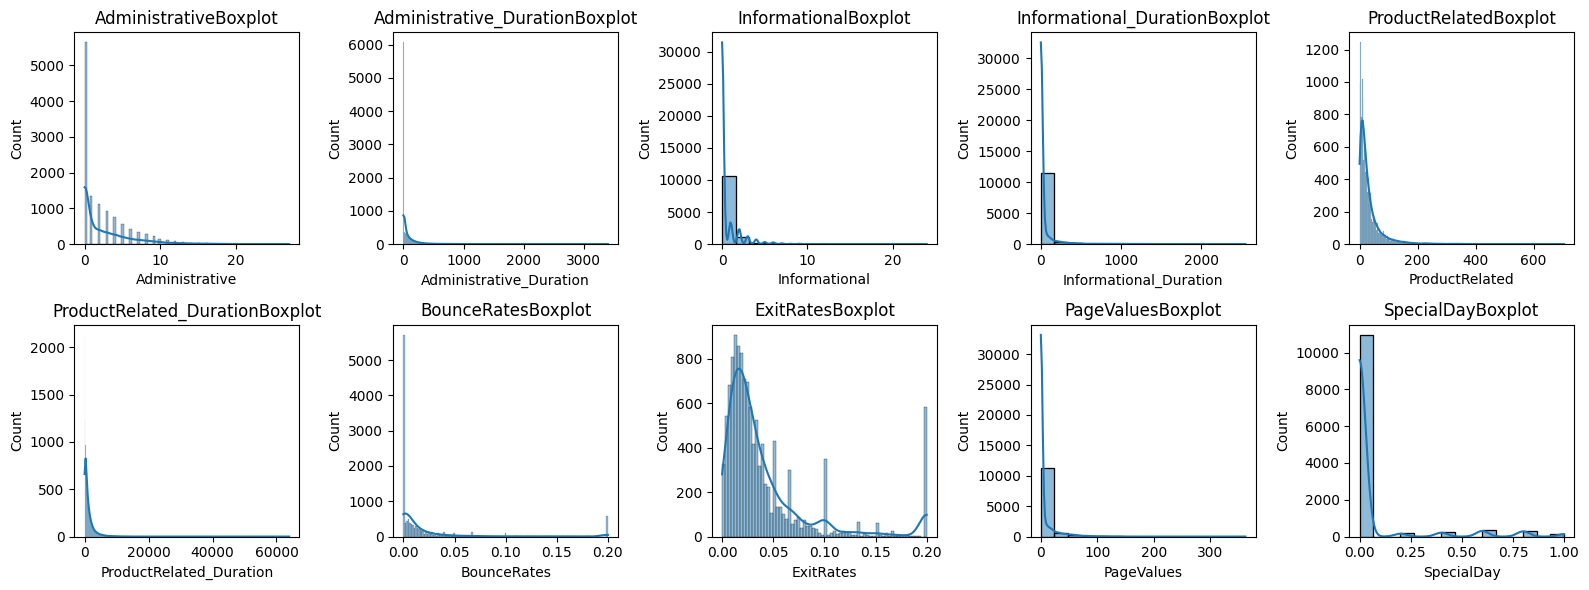

In [ ]:
numerical_columns = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

rows = math.ceil(len(numerical_columns) / 5)
fig, axes = plt.subplots(rows, 5, figsize=(16, 6))
axes = axes.flatten()

for i, column in enumerate(numerical_columns):
    sns.histplot(df[column], kde=True, ax=axes[i])
    axes[i].set_title(f"{column}Boxplot")

plt.tight_layout()
plt.show()

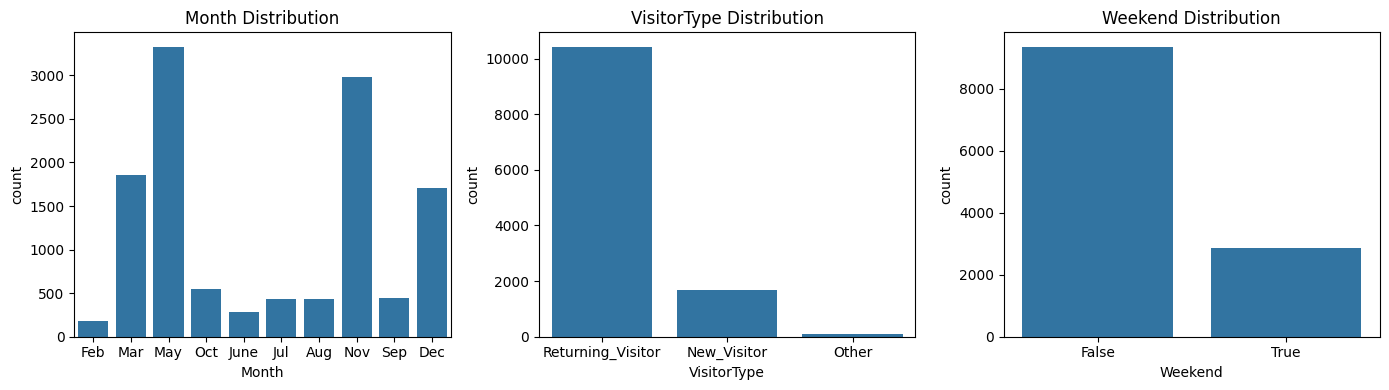

In [ ]:
categorical_columns = [
    'Month',
    'VisitorType',
    'Weekend'
]

rows = math.ceil(len(categorical_columns) / 3)
fig, axes = plt.subplots(rows, 3, figsize=(14,4))

for i, column in enumerate(categorical_columns):
    sns.countplot(x=column, data=df, ax=axes[i])
    axes[i].set_title(f"{column} Distribution")


plt.tight_layout()
plt.show()

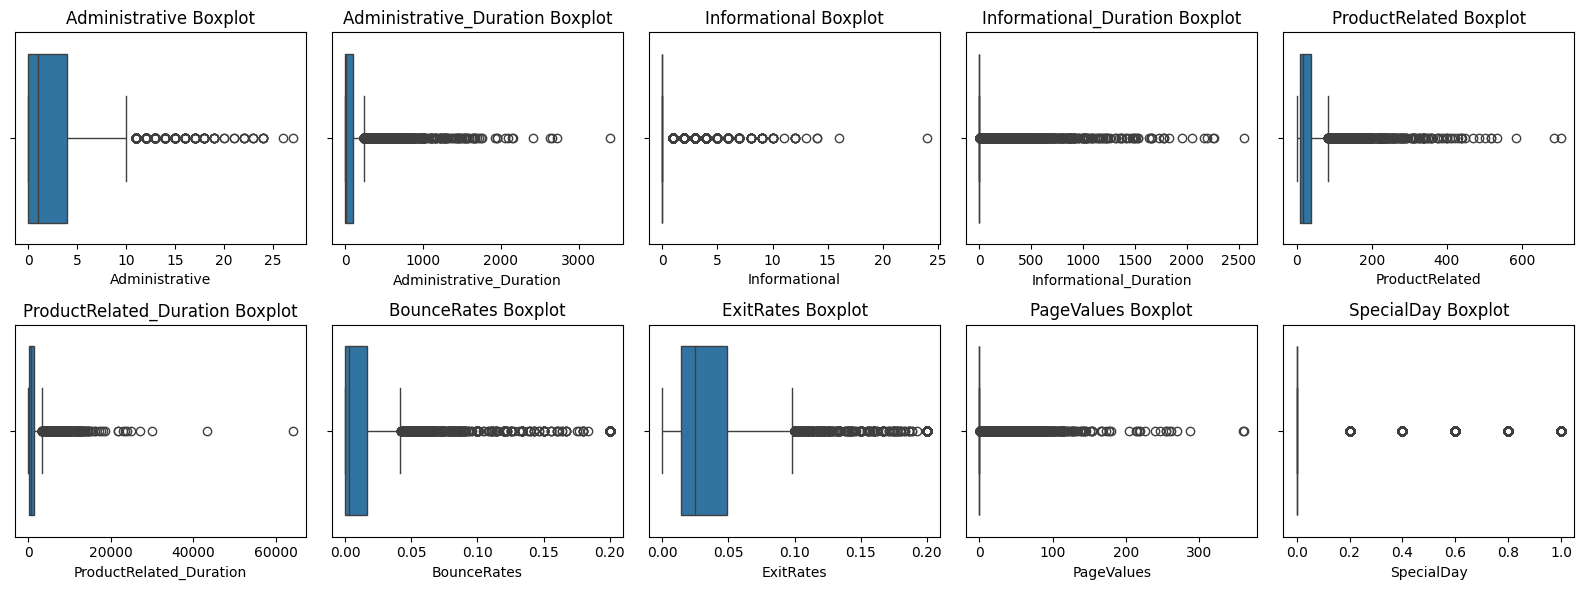

In [ ]:
outlier_summary = []

rows = math.ceil(len(numerical_columns) / 5)
fig, axes = plt.subplots(rows, 5, figsize=(16, 6))
axes = axes.flatten()

for i, columns in enumerate(numerical_columns):
  Q1 = df[columns].quantile(0.25)
  Q3 = df[columns].quantile(0.75)

  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = df[ (df[columns] < lower) | (df[columns] > upper) ]
  outlier_summary.append( [columns, len(outliers)])
  sns.boxplot(x=df[columns], ax=axes[i])
  axes[i].set_title(f"{columns} Boxplot")

plt.tight_layout()
plt.show()

In [ ]:
outlier_df = pd.DataFrame( outlier_summary, columns=["Feature", "Number_of_Outliers"] )
print("Outlier Summary:")
print(outlier_df)

Outlier Summary:
                   Feature  Number_of_Outliers
0           Administrative                 404
1  Administrative_Duration                1149
2            Informational                2631
3   Informational_Duration                2405
4           ProductRelated                1007
5  ProductRelated_Duration                 951
6              BounceRates                1428
7                ExitRates                1325
8               PageValues                2730
9               SpecialDay                1249


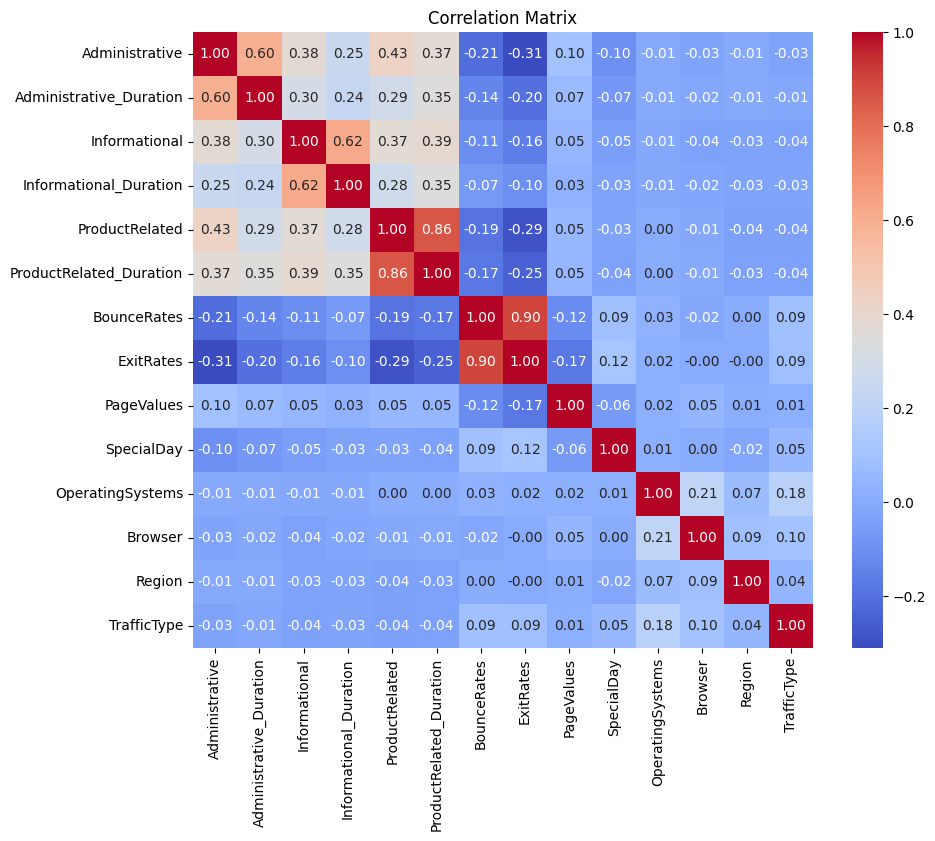

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt = ".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)

df = pd.get_dummies(
    df,
    columns=["Month", "VisitorType"],
    drop_first=True
)

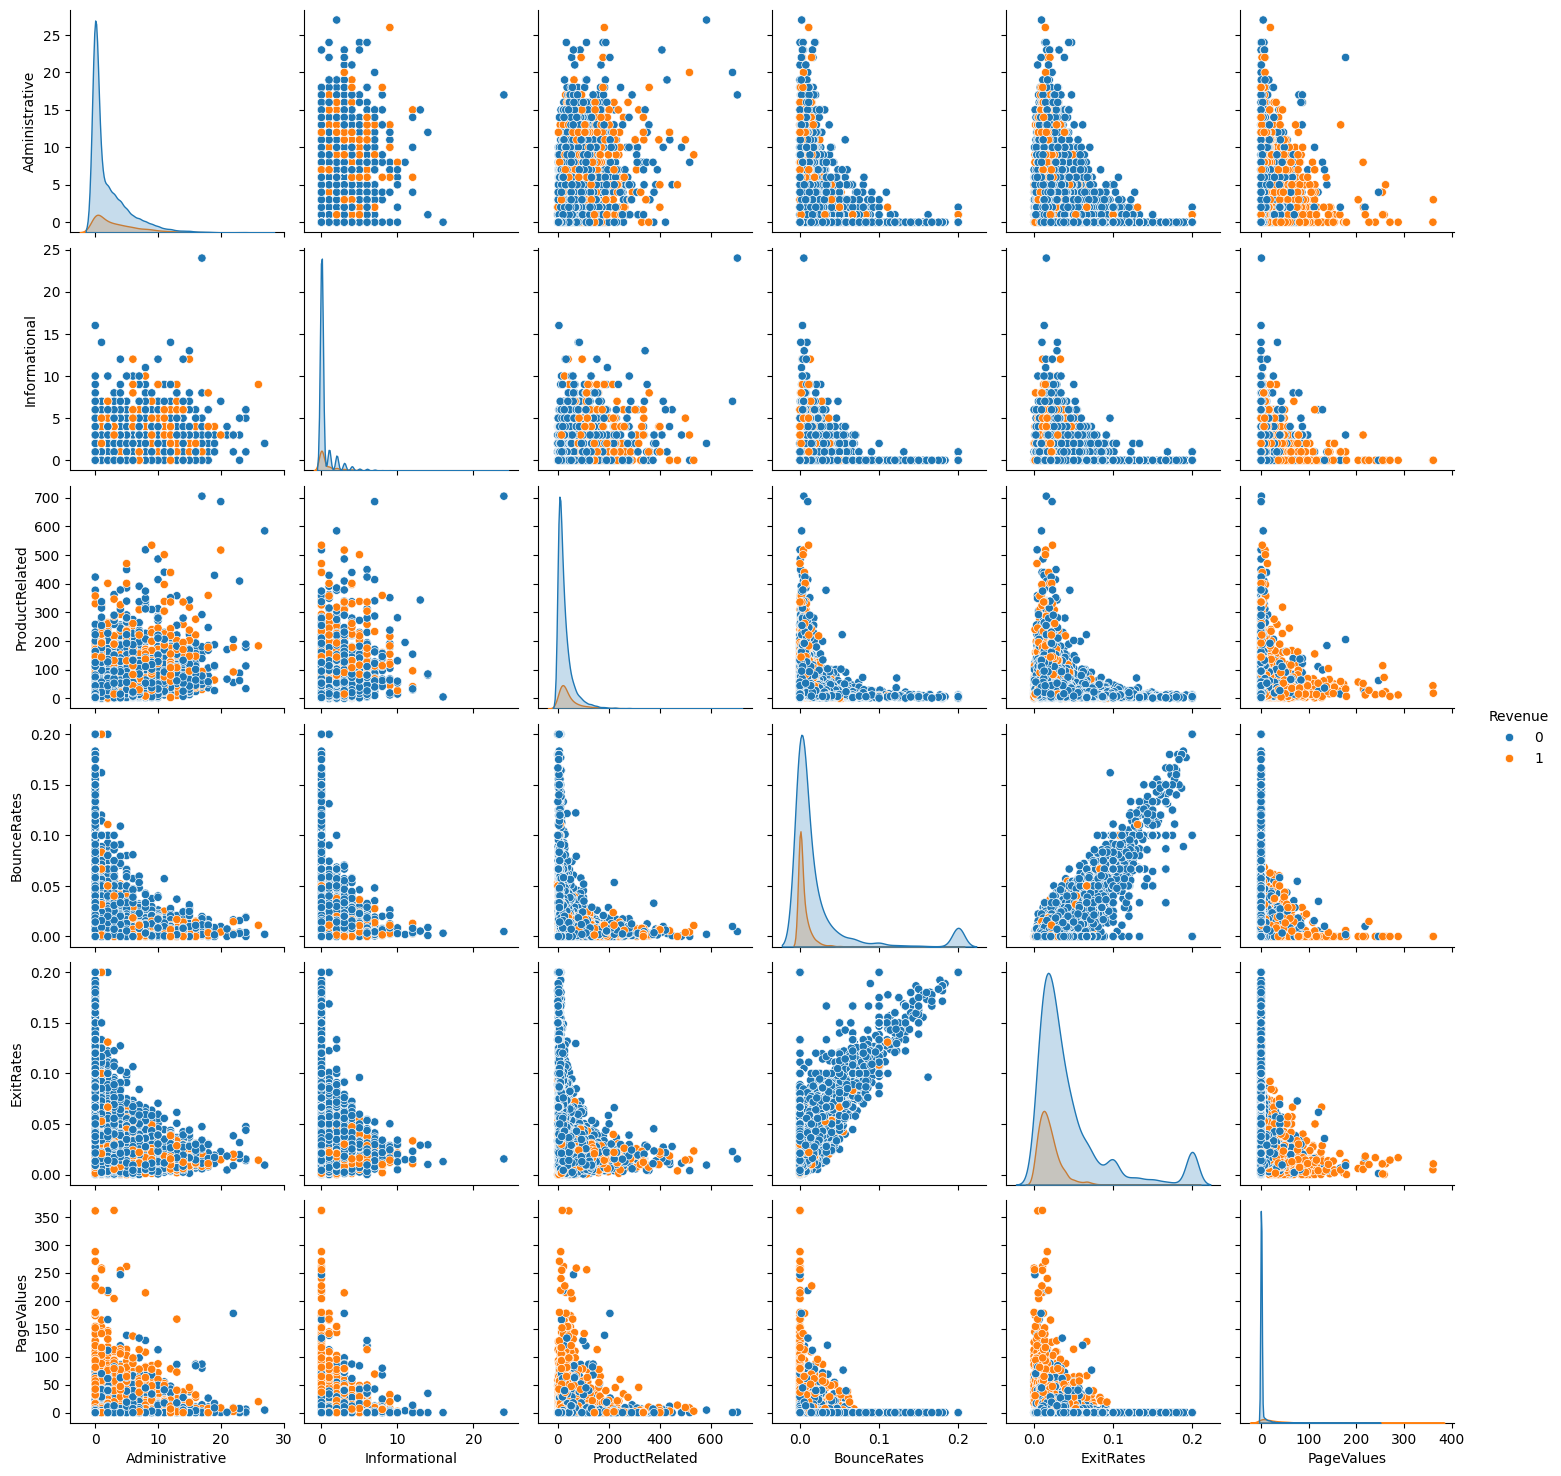

In [ ]:
sns.pairplot(
    df[
        [
            "Administrative",
            "Informational",
            "ProductRelated",
            "BounceRates",
            "ExitRates",
            "PageValues",
            "Revenue"
        ]
    ],
    hue="Revenue"
)

plt.show()

In [ ]:
X = df.drop(columns = ['Revenue'])
Y = df['Revenue']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Logistic Regression**
---

In [ ]:
# Logistic Regression
model_lr = LogisticRegression(class_weight='balanced') # to avoid model leaning towards a user not purchasing since 85% of the data the users dont end up purchasing
model_lr.fit(X_train_scaled,Y_train)
y_pred_logisticreg = model_lr.predict(X_test_scaled)

In [ ]:
print(classification_report(Y_test, y_pred_logisticreg, digits=3))

              precision    recall  f1-score   support

           0      0.956     0.864     0.907      2059
           1      0.516     0.785     0.623       382

    accuracy                          0.851      2441
   macro avg      0.736     0.824     0.765      2441
weighted avg      0.887     0.851     0.863      2441



In [ ]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [
        round(accuracy_score(Y_test, y_pred_logisticreg), 3),
        round(precision_score(Y_test, y_pred_logisticreg), 3),
        round(recall_score(Y_test, y_pred_logisticreg), 3),
        round(f1_score(Y_test, y_pred_logisticreg), 3),
        round(roc_auc_score(Y_test, y_pred_logisticreg), 3)
    ]
})
print("=== LOGISTIC REGRESSION RESULTS ===")
metrics_df

=== LOGISTIC REGRESSION RESULTS ===


,Metric,Score
0,Accuracy,0.851
1,Precision,0.516
2,Recall,0.785
3,F1 Score,0.623
4,ROC-AUC,0.824


In [ ]:
print(confusion_matrix(Y_test, y_pred_logisticreg))

[[1778  281]
 [  82  300]]


### **Applying PCA**
---



In [ ]:
# PCA
pca = PCA(n_components=0.9)
x_train_pca = pca.fit_transform(X_train_scaled)
x_test_pca = pca.transform(X_test_scaled)

print("Original shape: ",X_train_scaled.shape)
print("Reduced shape: ",x_train_pca.shape)
print("Explained variance ratio: ",round(pca.explained_variance_ratio_.sum(), 4))

Original shape:  (9764, 26)
Reduced shape:  (9764, 19)
Explained variance ratio:  0.9168


In [ ]:
# Apply logistic regression after pca
model_lr.fit(x_train_pca,Y_train)
y_pred_pca = model_lr.predict(x_test_pca)

metrics_pca_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [
        round(accuracy_score(Y_test, y_pred_pca), 3),
        round(precision_score(Y_test, y_pred_pca), 3),
        round(recall_score(Y_test, y_pred_pca), 3),
        round(f1_score(Y_test, y_pred_pca), 3),
        round(roc_auc_score(Y_test, y_pred_pca), 3)
    ]
})
print("=== LOGISTIC REGRESSION + PCA RESULTS ===")
metrics_pca_df

=== LOGISTIC REGRESSION + PCA RESULTS ===


,Metric,Score
0,Accuracy,0.858
1,Precision,0.531
2,Recall,0.783
3,F1 Score,0.633
4,ROC-AUC,0.827


In [ ]:
print(classification_report(Y_test, y_pred_pca, digits=3))

              precision    recall  f1-score   support

           0      0.956     0.872     0.912      2059
           1      0.531     0.783     0.633       382

    accuracy                          0.858      2441
   macro avg      0.743     0.827     0.772      2441
weighted avg      0.889     0.858     0.868      2441



In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred_pca))

Confusion Matrix:
[[1795  264]
 [  83  299]]


### **Comparison (LR VS LR + PCA)**
---



In [ ]:
print('-'*20 + "\nBefore PCA\n" + '-'*20 + '\n', metrics_df ,'\n' + '-'*20 + "\nAfter PCA\n" + '-'*20+ '\n', metrics_pca_df)

--------------------
Before PCA
--------------------
       Metric  Score
0   Accuracy  0.851
1  Precision  0.516
2     Recall  0.785
3   F1 Score  0.623
4    ROC-AUC  0.824 
--------------------
After PCA
--------------------
       Metric  Score
0   Accuracy  0.858
1  Precision  0.531
2     Recall  0.783
3   F1 Score  0.633
4    ROC-AUC  0.827


### **SVM**

---



In [ ]:
svm_model = SVC(kernel='rbf', C=1.0, random_state=42, class_weight='balanced')
svm_model.fit(X_train_scaled, Y_train)

Y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
print(classification_report(Y_test, Y_pred_svm, digits=3))

              precision    recall  f1-score   support

           0      0.952     0.882     0.916      2059
           1      0.544     0.759     0.634       382

    accuracy                          0.863      2441
   macro avg      0.748     0.821     0.775      2441
weighted avg      0.888     0.863     0.871      2441



In [ ]:
SVM_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [
        round(accuracy_score(Y_test, Y_pred_svm), 3),
        round(precision_score(Y_test, Y_pred_svm), 3),
        round(recall_score(Y_test, Y_pred_svm), 3),
        round(f1_score(Y_test, Y_pred_svm), 3),
        round(roc_auc_score(Y_test, Y_pred_svm), 3)
    ]
})
print("=== SVM RESULTS ===")
SVM_metrics

=== SVM RESULTS ===


,Metric,Score
0,Accuracy,0.863
1,Precision,0.544
2,Recall,0.759
3,F1 Score,0.634
4,ROC-AUC,0.821


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_svm))


Confusion Matrix:
[[1816  243]
 [  92  290]]


### **Decision Tree**
---



In [ ]:
model_dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=10,
    max_features=None,
    criterion='gini',
    class_weight=None,
    random_state=42
)
model_dt.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=10,
                       random_state=42)

In [ ]:
probabilities = model_dt.predict_proba(X_train)[:, 1]
Y_pred_decisiontree = (probabilities >= 0.45).astype(int)
print(classification_report(Y_train, Y_pred_decisiontree, digits=3))

              precision    recall  f1-score   support

           0      0.939     0.954     0.946      8238
           1      0.728     0.663     0.694      1526

    accuracy                          0.909      9764
   macro avg      0.833     0.809     0.820      9764
weighted avg      0.906     0.909     0.907      9764



In [ ]:
probabilities = model_dt.predict_proba(X_test)[:, 1]
Y_pred_decisiontree  = (probabilities >= 0.45).astype(int)
print(classification_report(Y_test, Y_pred_decisiontree, digits=3))

              precision    recall  f1-score   support

           0      0.935     0.948     0.941      2059
           1      0.695     0.644     0.668       382

    accuracy                          0.900      2441
   macro avg      0.815     0.796     0.805      2441
weighted avg      0.897     0.900     0.898      2441



In [ ]:
metrics_tree = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [
        round(accuracy_score(Y_test, Y_pred_decisiontree), 3),
        round(precision_score(Y_test, Y_pred_decisiontree), 3),
        round(recall_score(Y_test, Y_pred_decisiontree), 3),
        round(f1_score(Y_test, Y_pred_decisiontree), 3),
        round(roc_auc_score(Y_test, model_dt.predict_proba(X_test)[:, 1]), 3)
    ]
})

print("=== DECISION TREE RESULTS ===")
metrics_tree

=== DECISION TREE RESULTS ===


,Metric,Score
0,Accuracy,0.900
1,Precision,0.695
2,Recall,0.644
3,F1 Score,0.668
4,ROC-AUC,0.925


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_decisiontree))


Confusion Matrix:
[[1951  108]
 [ 136  246]]


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 7, 10,15],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, Y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 10}


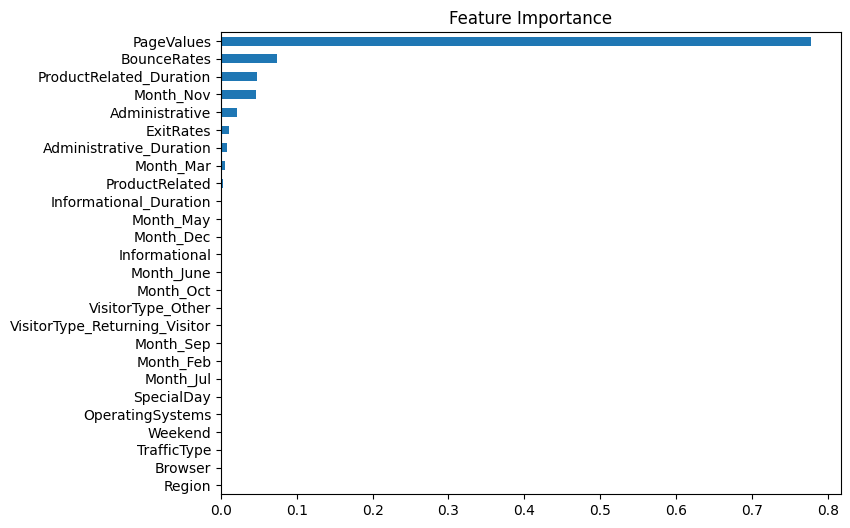

In [ ]:
#  Feature Importance

feat_imp = pd.Series(model_dt.feature_importances_, index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance")
plt.show()

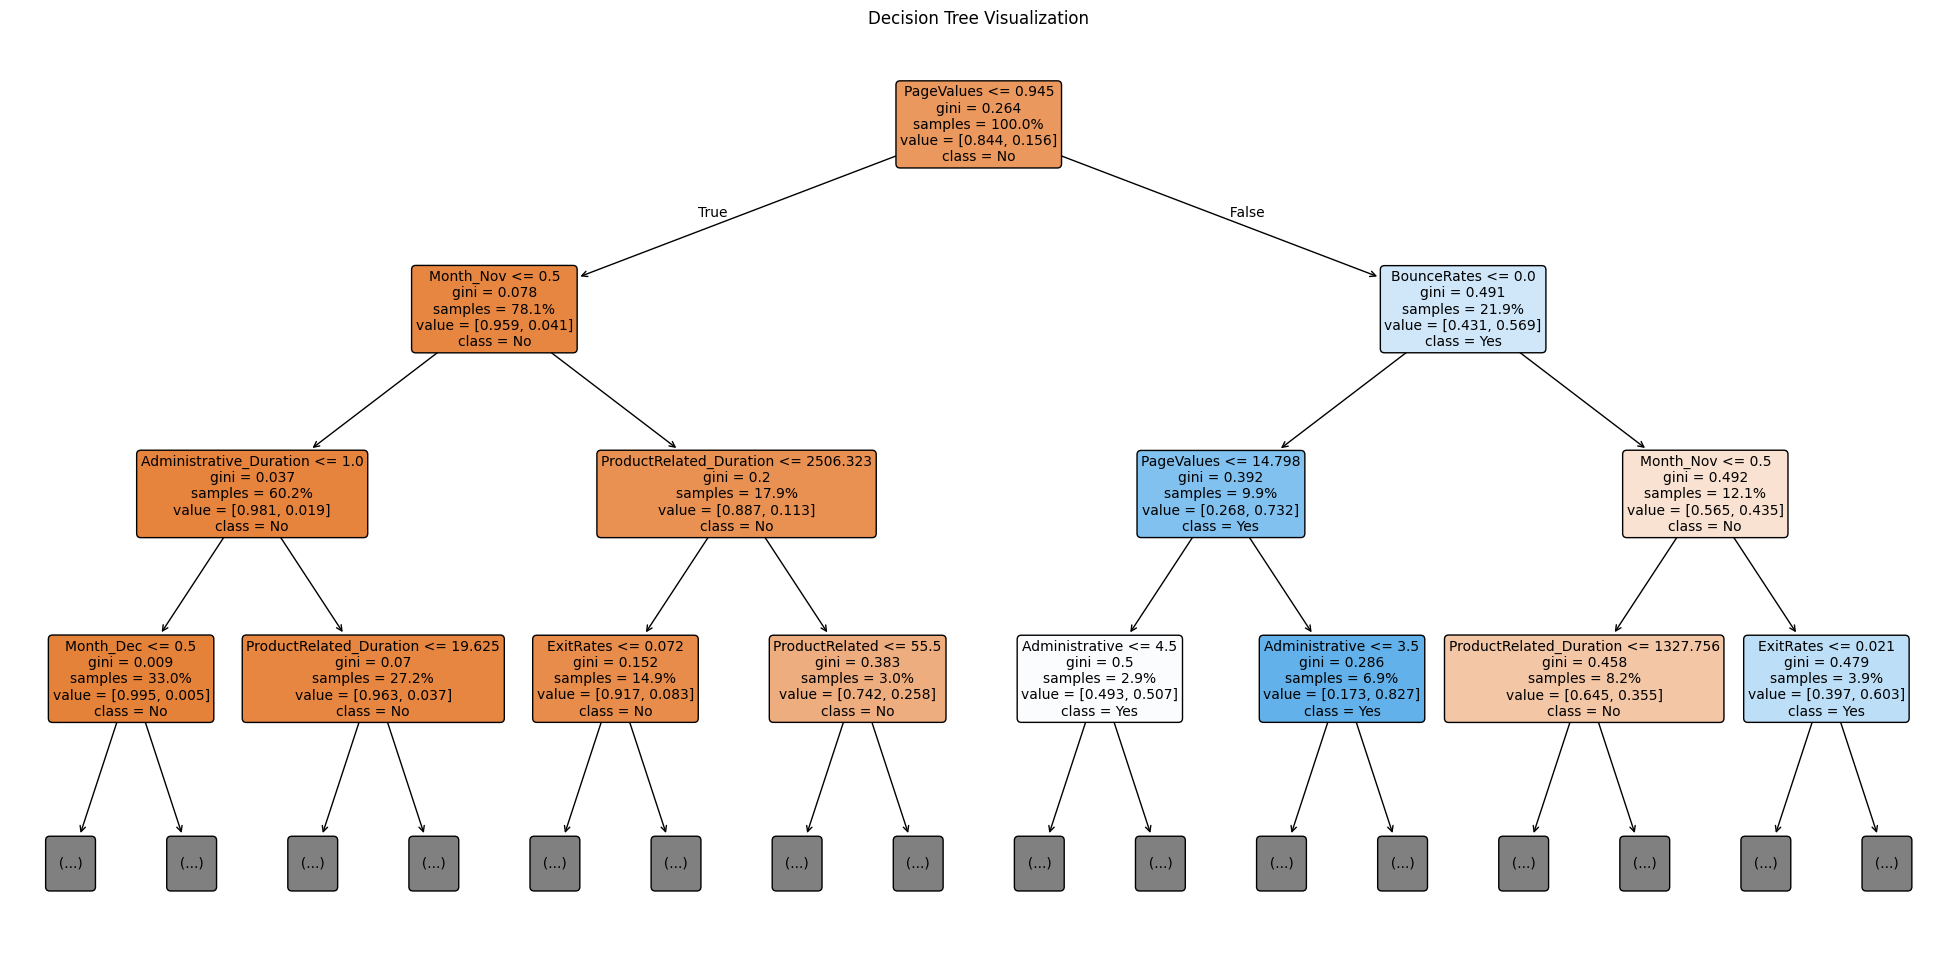

In [ ]:
#  Plot Tree
plt.figure(figsize=(25, 12))

plot_tree(
    model_dt,
    feature_names=X_train.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10,
    proportion=True
)

plt.title("Decision Tree Visualization")
plt.show()


### **Random Forest**
---

In [ ]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=8,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
)
model_rf.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=7, min_samples_leaf=8,
                       min_samples_split=10, n_estimators=200, random_state=42)

In [ ]:
probabilities = model_rf.predict_proba(X_train)[:, 1]
Y_pred_randomforest = (probabilities >= 0.45).astype(int)
print(classification_report(Y_train, Y_pred_randomforest, digits=3))

              precision    recall  f1-score   support

           0      0.974     0.861     0.914      8238
           1      0.538     0.875     0.666      1526

    accuracy                          0.863      9764
   macro avg      0.756     0.868     0.790      9764
weighted avg      0.906     0.863     0.875      9764



In [ ]:
probabilities = model_rf.predict_proba(X_test)[:, 1]
Y_pred_randomforest = (probabilities >= 0.45).astype(int)
print(classification_report(Y_test, Y_pred_randomforest, digits=3))

              precision    recall  f1-score   support

           0      0.972     0.859     0.912      2059
           1      0.532     0.866     0.659       382

    accuracy                          0.860      2441
   macro avg      0.752     0.863     0.786      2441
weighted avg      0.903     0.860     0.872      2441



In [ ]:
metrics_randomforest_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [
        round(accuracy_score(Y_test, Y_pred_randomforest), 3),
        round(precision_score(Y_test, Y_pred_randomforest), 3),
        round(recall_score(Y_test, Y_pred_randomforest), 3),
        round(f1_score(Y_test, Y_pred_randomforest), 3),
        round(roc_auc_score(Y_test, model_rf.predict_proba(X_test)[:, 1]), 3)
    ]
})
print("=== RANDOM FOREST RESULTS ===")
metrics_randomforest_df

=== RANDOM FOREST RESULTS ===


,Metric,Score
0,Accuracy,0.860
1,Precision,0.532
2,Recall,0.866
3,F1 Score,0.659
4,ROC-AUC,0.932


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_randomforest))


Confusion Matrix:
[[1768  291]
 [  51  331]]


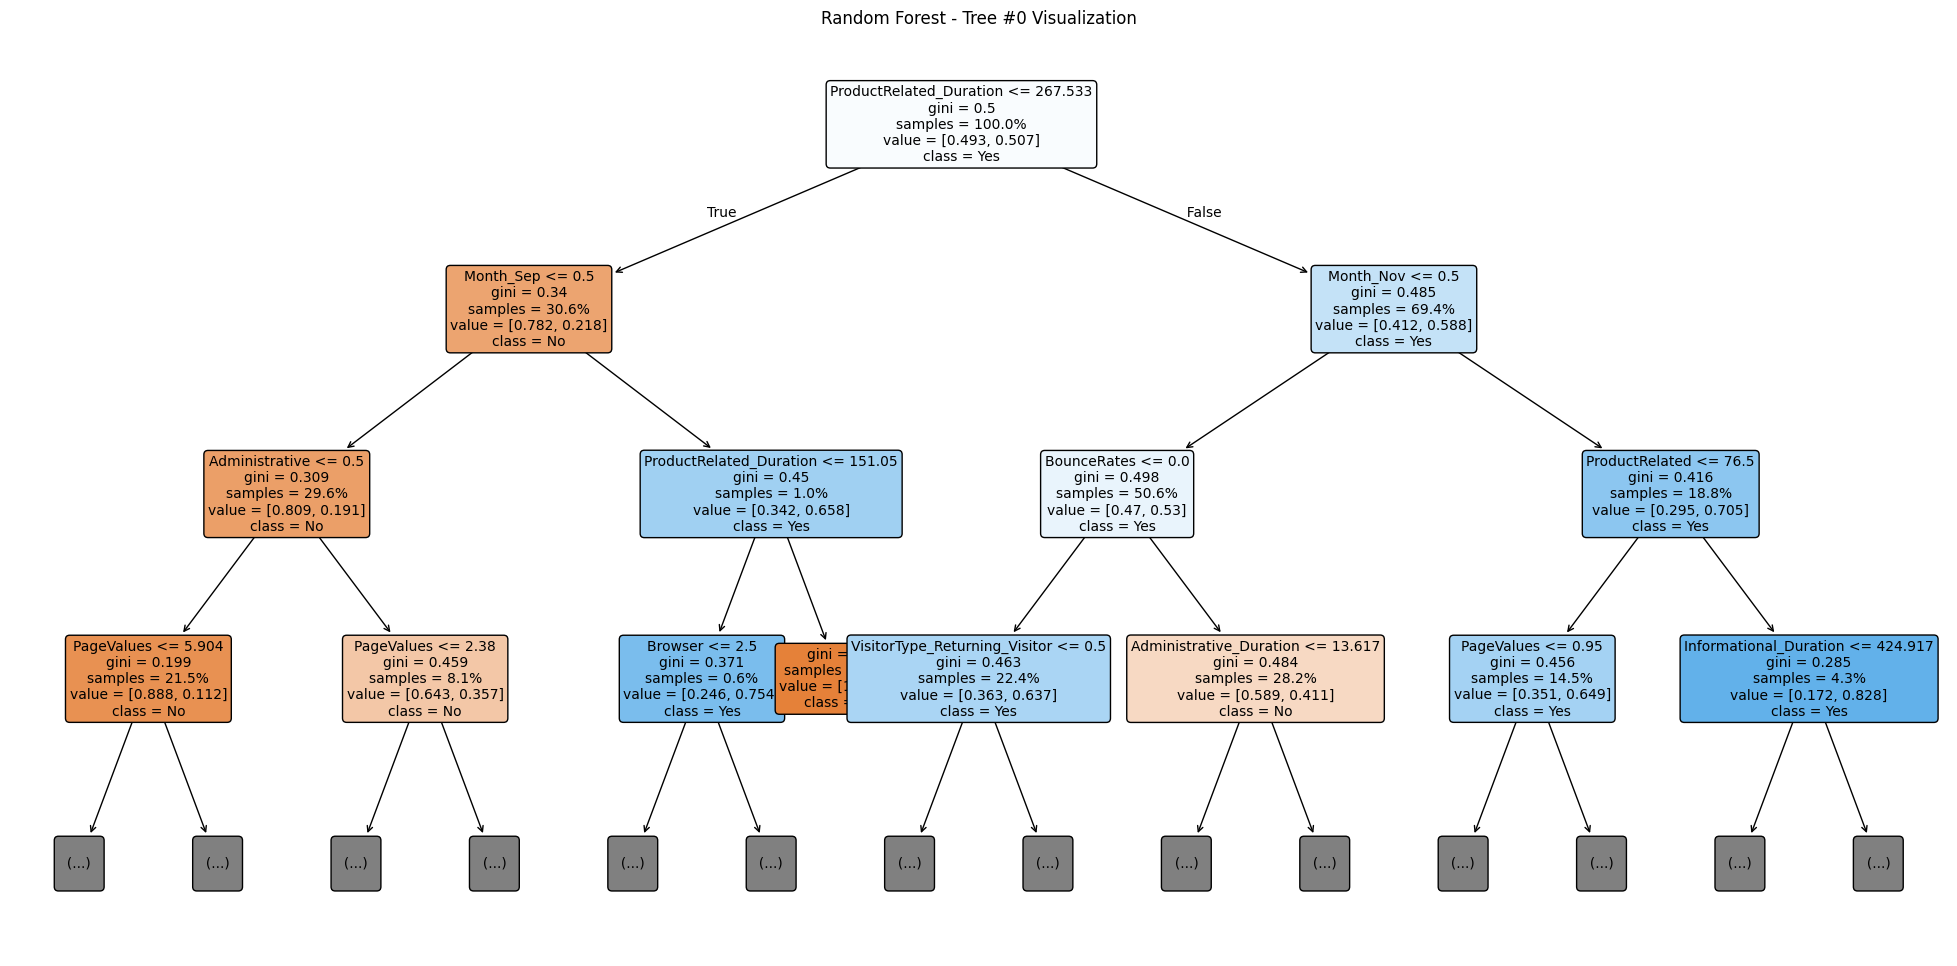

In [ ]:
plt.figure(figsize=(25, 12))
plot_tree(
    model_rf.estimators_[0],
    feature_names=X_train.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10,
    proportion=True
)
plt.title("Random Forest - Tree #0 Visualization")
plt.show()

### **XGBoost**
---

In [ ]:
model_xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
model_xgb.fit(X_train, Y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
probabilities = model_xgb.predict_proba(X_train)[:, 1]
Y_pred_xgboost = (probabilities >= 0.45).astype(int)
print(classification_report(Y_train, Y_pred_xgboost, digits=3))

              precision    recall  f1-score   support

           0      0.945     0.962     0.953      8238
           1      0.772     0.699     0.734      1526

    accuracy                          0.921      9764
   macro avg      0.859     0.830     0.844      9764
weighted avg      0.918     0.921     0.919      9764



In [ ]:
probabilities = model_xgb.predict_proba(X_test)[:, 1]
Y_pred_xgboost = (probabilities >= 0.45).astype(int)
print(classification_report(Y_test, Y_pred_xgboost, digits=3))

              precision    recall  f1-score   support

           0      0.944     0.950     0.947      2059
           1      0.722     0.694     0.708       382

    accuracy                          0.910      2441
   macro avg      0.833     0.822     0.827      2441
weighted avg      0.909     0.910     0.910      2441



In [ ]:
metrics_xgboost_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [
        round(accuracy_score(Y_test, Y_pred_xgboost), 3),
        round(precision_score(Y_test, Y_pred_xgboost), 3),
        round(recall_score(Y_test, Y_pred_xgboost), 3),
        round(f1_score(Y_test, Y_pred_xgboost), 3),
        round(roc_auc_score(Y_test, model_xgb.predict_proba(X_test)[:, 1]), 3)
    ]
})
print("=== XGBOOST RESULTS ===")
metrics_xgboost_df

=== XGBOOST RESULTS ===


,Metric,Score
0,Accuracy,0.910
1,Precision,0.722
2,Recall,0.694
3,F1 Score,0.708
4,ROC-AUC,0.939


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_xgboost))


Confusion Matrix:
[[1957  102]
 [ 117  265]]


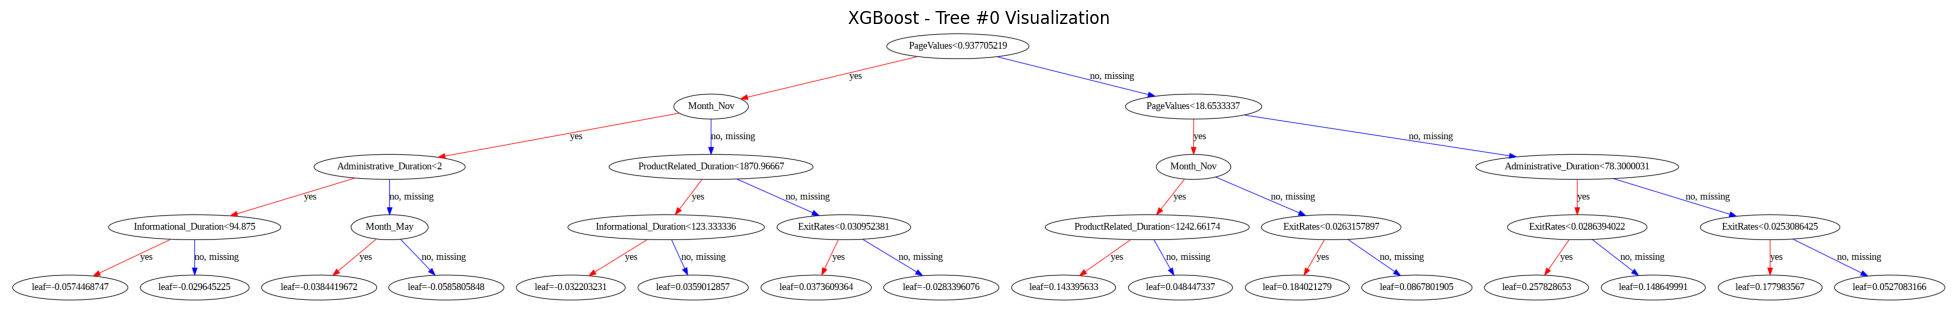

In [ ]:
fig, ax = plt.subplots(figsize=(25, 12))
xgb.plot_tree(
    model_xgb,
    tree_idx=0,
    ax=ax,
    rankdir='UT'
)
plt.title("XGBoost - Tree #0 Visualization")
plt.show()

# **FINAL MODEL COMPARISON**
---

In [ ]:
finalcomparison_df = pd.DataFrame({
    "Logistic Regression": metrics_df.set_index("Metric")["Score"],
    "Logistic Regression + PCA": metrics_pca_df.set_index("Metric")["Score"],
    "SVM": SVM_metrics.set_index("Metric")["Score"],
    "Decision Tree": metrics_tree.set_index("Metric")["Score"],
    "Random Forest": metrics_randomforest_df.set_index("Metric")["Score"],
    "XGBoost": metrics_xgboost_df.set_index("Metric")["Score"]
}).T
finalcomparison_df

Metric,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.851,0.516,0.785,0.623,0.824
Logistic Regression + PCA,0.858,0.531,0.783,0.633,0.827
SVM,0.863,0.544,0.759,0.634,0.821
Decision Tree,0.900,0.695,0.644,0.668,0.925
Random Forest,0.860,0.532,0.866,0.659,0.932
XGBoost,0.910,0.722,0.694,0.708,0.939


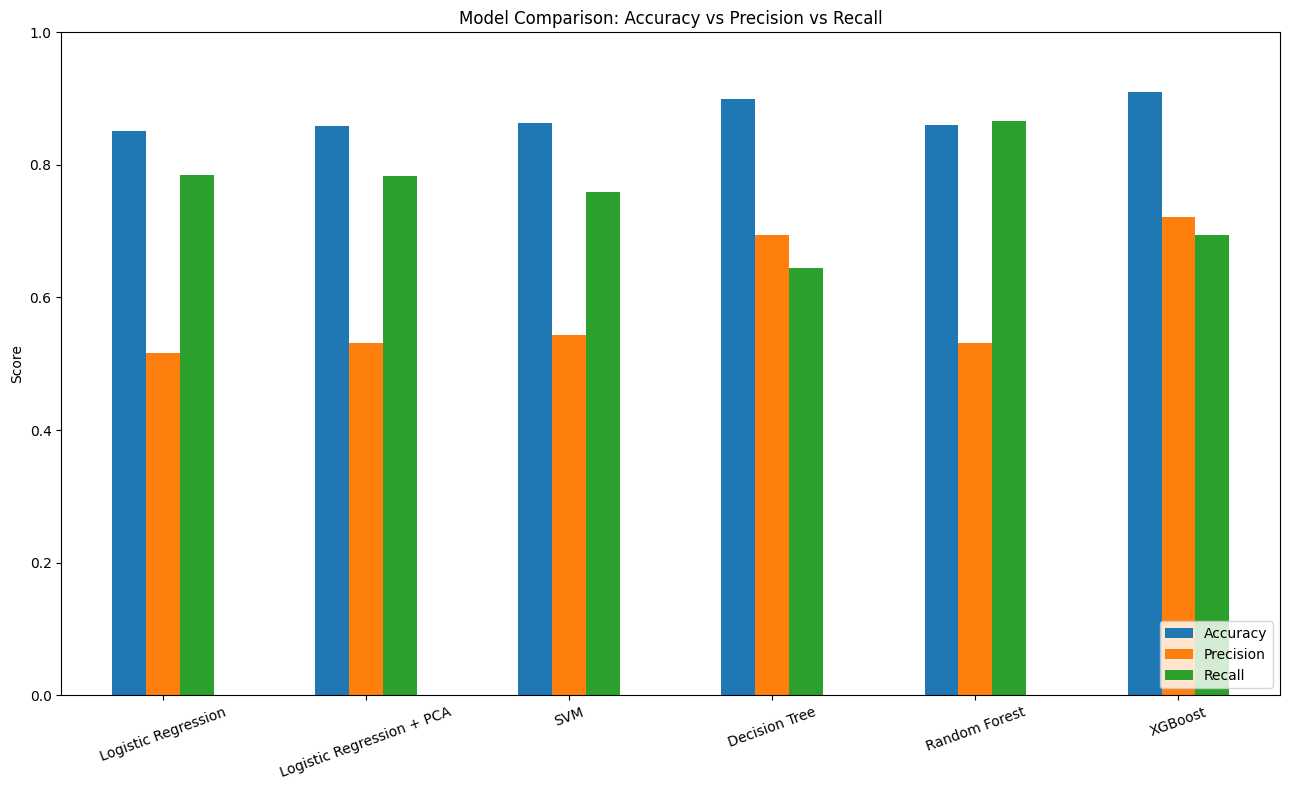

In [ ]:
finalcomparison_df[["Accuracy", "Precision", "Recall"]].plot(
    kind="bar", figsize=(13, 8)
)
plt.title("Model Comparison: Accuracy vs Precision vs Recall")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()